In [1]:
import sys
sys.path.append('../../')
from notebook_utils import plot_dset, plot_contour

import numpy as np
import pylab as plt

import torch
import torch.nn as nn

from sklearn import datasets
import lightning as L

from dal_toolbox.models.sngp import SNGPModel
from dal_toolbox.models.deterministic.simplenet import SimpleSNGP as Net
from dal_toolbox.models.utils.callbacks import MetricHistory

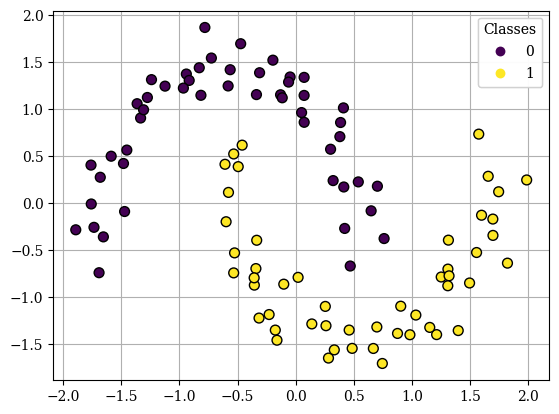

In [2]:
X, y = datasets.make_moons(100, noise=.1, random_state=42)
X = (X - X.mean(0)) / X.std(0)
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).long()

train_ds = torch.utils.data.TensorDataset(X, y)

plot_dset(X_l=X, y_l=y)
plt.show()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params
---------------------------------------------------
0 | model         | SimpleSNGP       | 101 K 
1 | loss_fn       | CrossEntropyLoss | 0     
2 | train_metrics | ModuleDict       | 0     
3 | val_metrics   | ModuleDict       | 0     
---------------------------------------------------
101 K     Trainable params
0         Non-trainable params
101 K     Total params
0.406     Total estimated model params size (MB)


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


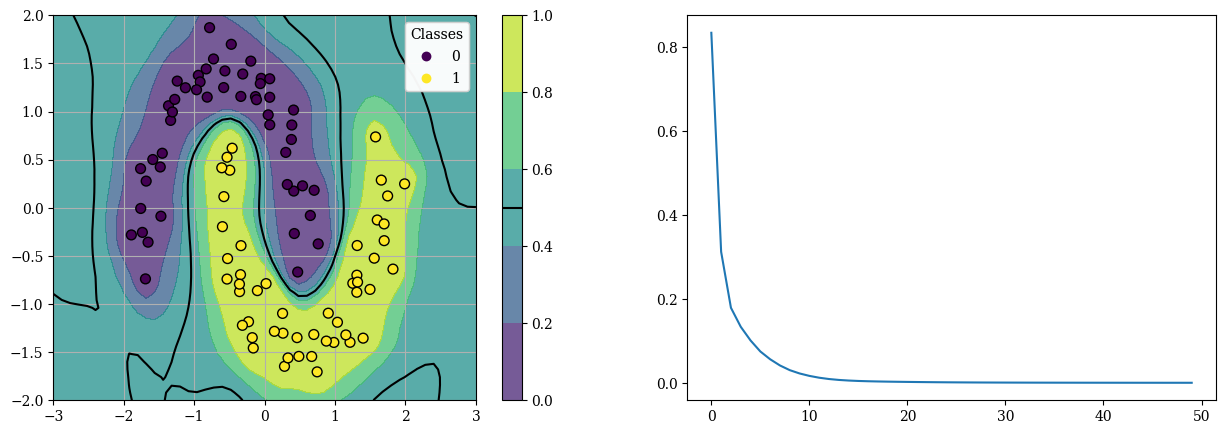

In [3]:
spectral_norm_params = dict(
    norm_bound=.9,
    n_power_iterations=1
)
gp_params = dict(
    num_inducing=1024,
    kernel_scale=0.05,
    random_feature_type='orf',
    scale_random_features=False,
    # normalize_input=False,
    # mean_field_factor=1,
    # cov_momentum=-1,
    # ridge_penalty=1
)
epochs = 50

torch.manual_seed(0)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True)

model = Net(num_classes=2, use_spectral_norm=True, spectral_norm_params=spectral_norm_params, gp_params=gp_params)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2, weight_decay=1e-2, momentum=.9)
model = SNGPModel(
    model,
    optimizer=optimizer
)
history = MetricHistory()
trainer = L.Trainer(max_epochs=epochs, callbacks=[history])
trainer.fit(model, train_loader)

model.eval()
plt.figure(figsize=(15, 5))
plot_contour(model, X_l=X, y_l=y, ax=plt.subplot(121), forward_mode='mean_field', x_domain=(-3, 3), y_domain=(-2, 2))
plt.subplot(122)
plt.plot([d['train_loss'] for d in history])
plt.show()